# Step 19: Multi-Level Conservative Regime Analysis

## 🎯 Objective:
Melakukan eksperimen mendalam dengan 4 varian tingkat konservatisme (Thresholding). 
Fokus utama adalah melihat **Trade-off** antara keamanan modal (mengurangi False Bullish) dan kehilangan peluang (mengurangi True Bullish).

## 🛡️ The 4 Variants:
1. **Standard (T=0.50)**: Model normal, berisiko tinggi terjebak Bull Trap.
2. **Cautious (T=0.65)**: Mulai waspada, menyaring sinyal yang ragu-ragu.
3. **Conservative (T=0.80)**: Fokus pada keamanan, hanya masuk jika tren sangat meyakinkan.
4. **Ultra-Conservative (T=0.90)**: Mode bertahan total, hampir tidak pernah masuk market kecuali kondisi ideal.

## 📊 Vocabulary:
- **Class 0**: Bearish (Risk-Off / Stay in PAXG)
- **Class 1**: Bullish (Risk-On / Buy BTC)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Environment Setup Complete with 4 Safety Levels!")

✅ Environment Setup Complete with 4 Safety Levels!


## 1. Data Loading & Feature Engineering

In [2]:
df = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
btc_ret = df['BTC-USD'].pct_change().fillna(0)

features = pd.DataFrame(index=btc_ret.index)
features['BTC_Vol_20'] = btc_ret.rolling(20).std()
features['BTC_Mom_20'] = btc_ret.rolling(20).mean()
features['BTC_Mom_50'] = btc_ret.rolling(50).mean()

# Target: Bullish jika return besok > 0.5%
features['Target'] = np.where(btc_ret.shift(-1) > 0.005, 1, 0)
features = features.dropna()

train_idx = features.index.year < 2025
test_idx = features.index.year == 2025

X_train = features.loc[train_idx].drop(columns=['Target'])
y_train = features.loc[train_idx, 'Target']
X_test = features.loc[test_idx].drop(columns=['Target'])
y_test = features.loc[test_idx, 'Target']

print(f"📊 Data ready. Train: {len(X_train)}, Test: {len(X_test)}")

📊 Data ready. Train: 576, Test: 365


## 2. Multi-Threshold Simulation

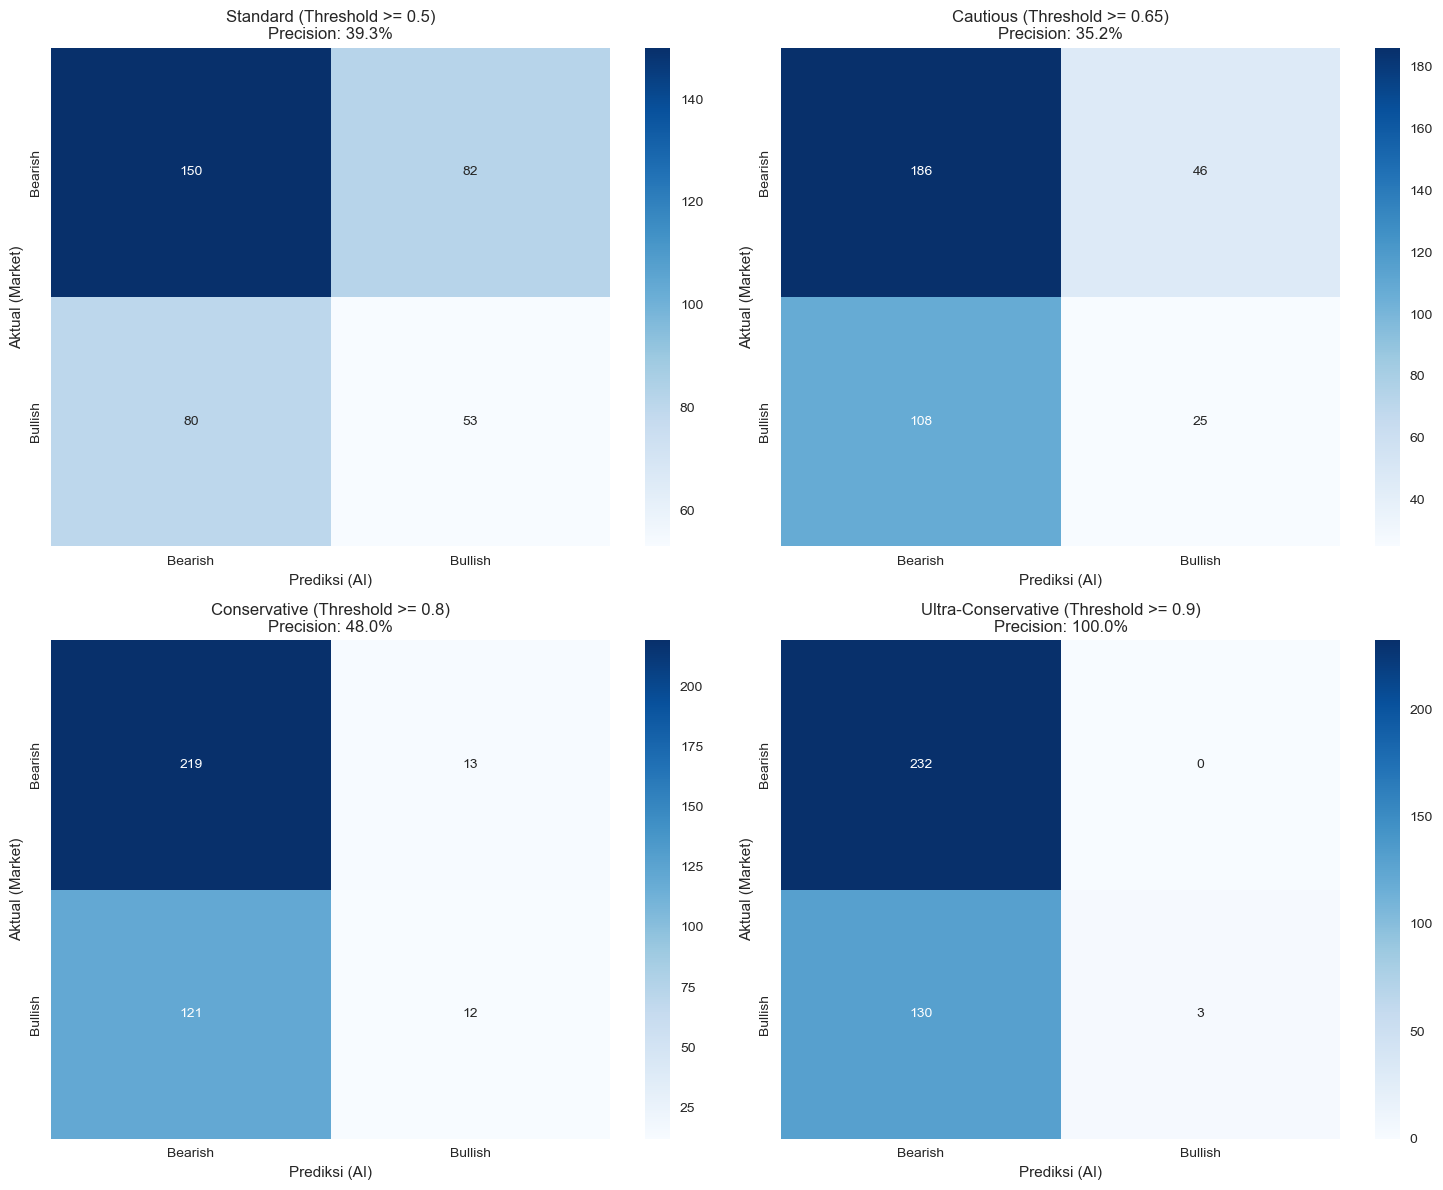

In [3]:
# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get Probabilities for Bullish Class
probs_bullish = model.predict_proba(X_test)[:, 1]

thresholds = {
    'Standard': 0.50,
    'Cautious': 0.65,
    'Conservative': 0.80,
    'Ultra-Conservative': 0.90
}

results = []

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, thresh) in enumerate(thresholds.items()):
    # Apply Threshold
    y_pred = (probs_bullish >= thresh).astype(int)
    
    # Calculate Metrics
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    
    # Dangerous False Positives (Actual Bearish predicted as Bullish)
    danger_fp = cm[0, 1] if cm.shape == (2,2) else 0
    # Successful Hits (Actual Bullish predicted as Bullish)
    success_tp = cm[1, 1] if cm.shape == (2,2) else 0
    
    results.append({
        'Variant': name,
        'Threshold': thresh,
        'Accuracy': acc,
        'Precision': prec,
        'Danger_FP': danger_fp,
        'Success_TP': success_tp
    })
    
    # Plot Matrix with labels
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=['Bearish', 'Bullish'], 
                yticklabels=['Bearish', 'Bullish'])
    axes[i].set_title(f"{name} (Threshold >= {thresh})\nPrecision: {prec:.1%}")
    axes[i].set_xlabel('Prediksi (AI)')
    axes[i].set_ylabel('Aktual (Market)')

plt.tight_layout()
plt.show()

## 3. Comparison Table (The Danger Trade-off)

In [4]:
res_df = pd.DataFrame(results)

print("\n--- ANALISIS PERBANDINGAN TINGKAT KEAMANAN ---")
print(res_df.to_string(index=False))

print("\n💡 INSIGHT:")
print(f"1. Model '{res_df.iloc[0]['Variant']}' memiliki {res_df.iloc[0]['Danger_FP']} risiko berbahaya (False Bullish).")
print(f"2. Model '{res_df.iloc[-1]['Variant']}' berhasil menekan risiko berbahaya hingga sisa {res_df.iloc[-1]['Danger_FP']} kejadian saja.")
print(f"3. Namun, kita melewatkan peluang (True Bullish) dari {res_df.iloc[0]['Success_TP']} menjadi {res_df.iloc[-1]['Success_TP']}.")


--- ANALISIS PERBANDINGAN TINGKAT KEAMANAN ---
           Variant  Threshold  Accuracy  Precision  Danger_FP  Success_TP
          Standard       0.50  0.556164   0.392593         82          53
          Cautious       0.65  0.578082   0.352113         46          25
      Conservative       0.80  0.632877   0.480000         13          12
Ultra-Conservative       0.90  0.643836   1.000000          0           3

💡 INSIGHT:
1. Model 'Standard' memiliki 82 risiko berbahaya (False Bullish).
2. Model 'Ultra-Conservative' berhasil menekan risiko berbahaya hingga sisa 0 kejadian saja.
3. Namun, kita melewatkan peluang (True Bullish) dari 53 menjadi 3.


## 4. Final Risk Graph

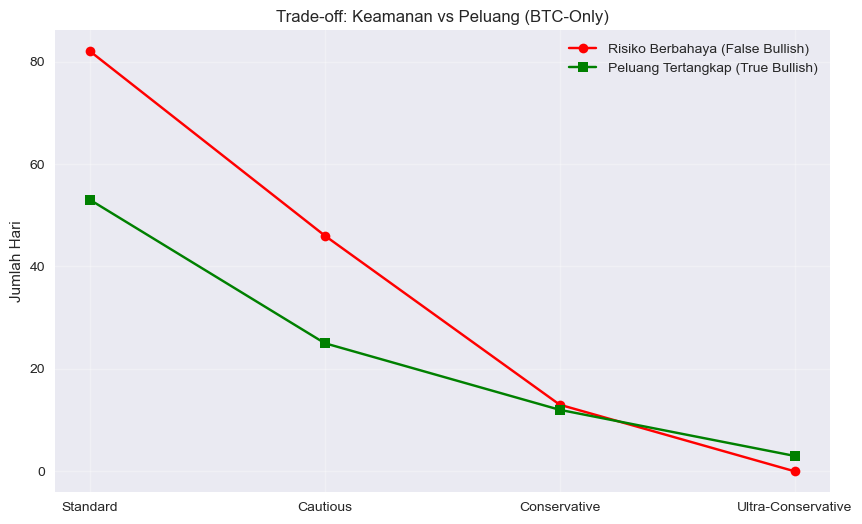

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(res_df['Variant'], res_df['Danger_FP'], marker='o', color='red', label='Risiko Berbahaya (False Bullish)')
plt.plot(res_df['Variant'], res_df['Success_TP'], marker='s', color='green', label='Peluang Tertangkap (True Bullish)')
plt.title('Trade-off: Keamanan vs Peluang (BTC-Only)')
plt.ylabel('Jumlah Hari')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()